In [19]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

G = 6.67 * 10 ** -11
M_1 = 10**35
M_2 = 5 * 10**34
M_3 = 2 * 10**35
c = 3 * 10 ** 8

D_s_1 = 10 ** 21
D_d_1 = 10**20
D_ds_1 = 9*10**20

D_s_2 = 1.2 * 10**21
D_d_2 = 10**20
D_ds_2 = D_s_2 - D_d_2

D_s_3 = 8 * 10**20
D_d_3 = 10**20
D_ds_3 = D_s_3 - D_d_3

θ_E_1 = np.sqrt((4*G*M_1)/(c**2)*D_ds_1/(D_d_1*D_s_1))
θ_E_2 = np.sqrt((4*G*M_2)/(c**2)*D_ds_2/(D_d_2*D_s_2))
θ_E_3 = np.sqrt((4*G*M_3)/(c**2)*D_ds_3/(D_d_3*D_s_3))

print(θ_E_1, θ_E_2, θ_E_3)

β_list_1 = [
    [0, 0],                          
    [-1*θ_E_1, 2*θ_E_1],
    [-θ_E_1, θ_E_1],
    [1.5*θ_E_1, -0.5*θ_E_1],
    [-2*θ_E_1, -θ_E_1]
]

β_list_2 = [
    [2*θ_E_1, -θ_E_1],
    [-1*θ_E_1, 0.5*θ_E_1],
    [0.25*θ_E_1, -1.5*θ_E_1],
    [1.2*θ_E_1, 1.8*θ_E_1],
    [-0.7*θ_E_1, 2*θ_E_1]
]


O1_list = [
    [0, 0],
    [0.5*θ_E_1, -0.5*θ_E_1],
    [-θ_E_1, 0],
    [0, 1.2*θ_E_1]
]

O2_list = [
    [2*θ_E_1, 0],
    [1.5*θ_E_1, 1.5*θ_E_1],
    [-1*θ_E_1, 1*θ_E_1],
    [2.5*θ_E_1, -1.5*θ_E_1]
]

O3_list = [
    [-1.5*θ_E_1, 1.5*θ_E_1],
    [-2*θ_E_1, -1*θ_E_1],
    [1*θ_E_1, -2*θ_E_1],
    [-1*θ_E_1, 2.5*θ_E_1]
]

print(β_list_1, β_list_2)
print(O1_list, O2_list, O3_list)


1.6334013591276333e-06 1.1656344640167875e-06 2.277669374114201e-06
[[0, 0], [-1.6334013591276333e-06, 3.2668027182552666e-06], [-1.6334013591276333e-06, 1.6334013591276333e-06], [2.45010203869145e-06, -8.167006795638167e-07], [-3.2668027182552666e-06, -1.6334013591276333e-06]] [[3.2668027182552666e-06, -1.6334013591276333e-06], [-1.6334013591276333e-06, 8.167006795638167e-07], [4.0835033978190833e-07, -2.45010203869145e-06], [1.96008163095316e-06, 2.94012244642974e-06], [-1.1433809513893433e-06, 3.2668027182552666e-06]]
[[0, 0], [8.167006795638167e-07, -8.167006795638167e-07], [-1.6334013591276333e-06, 0], [0, 1.96008163095316e-06]] [[3.2668027182552666e-06, 0], [2.45010203869145e-06, 2.45010203869145e-06], [-1.6334013591276333e-06, 1.6334013591276333e-06], [4.083503397819084e-06, -2.45010203869145e-06]] [[-2.45010203869145e-06, 2.45010203869145e-06], [-3.2668027182552666e-06, -1.6334013591276333e-06], [1.6334013591276333e-06, -3.2668027182552666e-06], [-1.6334013591276333e-06, 4.0835

In [20]:
from scipy.optimize import root

# Select sources and lens positions 
β_1 = np.array(β_list_1[1])
β_2 = np.array(β_list_2[1])

O_1 = np.array(O1_list[2])
O_2 = np.array(O2_list[2])
O_3 = np.array(O3_list[3])

# Lens equation function
def lens_equation(theta, beta):

    θ = np.array(theta)

    deflection = (
        θ_E_1**2 * (θ - O_1) / np.linalg.norm(θ - O_1)**2 +
        θ_E_2**2 * (θ - O_2) / np.linalg.norm(θ - O_2)**2 +
        θ_E_3**2 * (θ - O_3) / np.linalg.norm(θ - O_3)**2
    )

    return θ - deflection - beta


# Find image solutions
def find_images(beta):

    guesses = [
        [1e-6,0],
        [-1e-6,0],
        [0,1e-6],
        [0,-1e-6],
        [2e-6,2e-6],
        [-2e-6,-2e-6]
    ]

    solutions = []

    for g in guesses:

        sol = root(lens_equation, g, args=(beta,))

        if sol.success:
            θ = sol.x

            # avoid duplicates
            if not any(np.linalg.norm(θ - s) < 1e-8 for s in solutions):
                solutions.append(θ)

    return solutions


# Solve for images of both sources
images_1 = find_images(β_1)
images_2 = find_images(β_2)

print("Source 1 β =", β_1)
for i,θ in enumerate(images_1):
    print(f"θ_{i+1} =", θ)

print("\nSource 2 β =", β_2)
for i,θ in enumerate(images_2):
    print(f"θ_{i+1} =", θ)


# Magnification calculation
def magnification(theta, beta):

    eps = 1e-10

    # numerical derivatives
    dtheta_x = np.array([eps, 0])
    dtheta_y = np.array([0, eps])

    beta_x1 = lens_equation(theta + dtheta_x, beta)
    beta_x2 = lens_equation(theta - dtheta_x, beta)

    beta_y1 = lens_equation(theta + dtheta_y, beta)
    beta_y2 = lens_equation(theta - dtheta_y, beta)

    # partial derivatives
    dβ_dx = (beta_x1 - beta_x2) / (2 * eps)
    dβ_dy = (beta_y1 - beta_y2) / (2 * eps)

    # Jacobian matrix
    J = np.array([
        [dβ_dx[0], dβ_dy[0]],
        [dβ_dx[1], dβ_dy[1]]
    ])

    detJ = np.linalg.det(J)

    return 1 / abs(detJ)


# Magnifications for source 1
print("\nMagnifications for source 1:")
for θ in images_1:
    print(magnification(θ, β_1))

# Magnifications for source 2
print("\nMagnifications for source 2:")
for θ in images_2:
    print(magnification(θ, β_2))

Source 1 β = [-1.63340136e-06  3.26680272e-06]
θ_1 = [9.72598095e-07 3.75364408e-06]
θ_2 = [-1.63340136e-06 -9.84822915e-07]

Source 2 β = [-1.63340136e-06  8.16700680e-07]
θ_1 = [-6.64458207e-07 -1.64749351e-06]
θ_2 = [-1.63340136e-06 -1.86962568e-06]

Magnifications for source 1:
2.0150516507701943
0.11199523146377806

Magnifications for source 2:
12.854225569419162
24.294760293836607


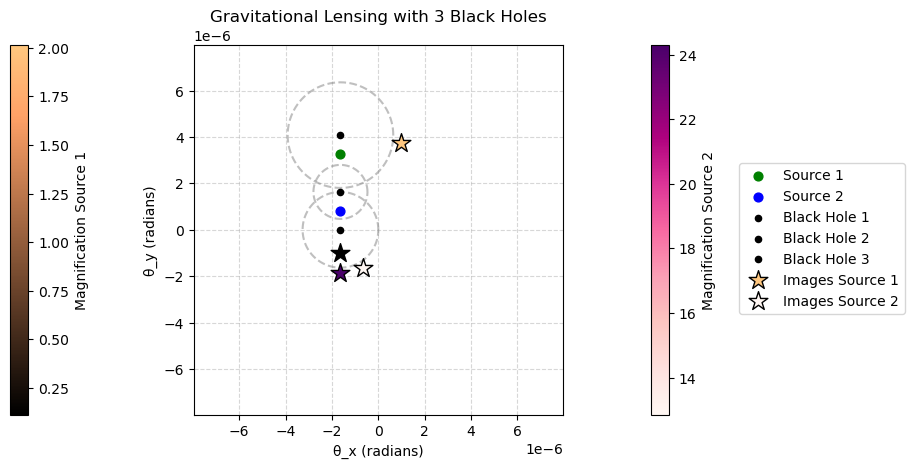

In [21]:
fig, ax = plt.subplots()

theta = np.linspace(0, 2*np.pi, 500)

# Plot Einstein radii
for O, theta_E in [(O_1, θ_E_1), (O_2, θ_E_2), (O_3, θ_E_3)]:
    x = O[0] + theta_E * np.cos(theta)
    y = O[1] + theta_E * np.sin(theta)
    ax.plot(x, y, color='gray', ls='--', alpha=0.5)

# Plot sources
ax.scatter(β_1[0], β_1[1], color='green', s=40, label='Source 1', zorder=7)
ax.scatter(β_2[0], β_2[1], color='blue', s=40, label='Source 2', zorder=7)

# Plot black holes
ax.scatter(O_1[0], O_1[1], color='black', s=20, label='Black Hole 1', zorder=6)
ax.scatter(O_2[0], O_2[1], color='black', s=20, label='Black Hole 2', zorder=6)
ax.scatter(O_3[0], O_3[1], color='black', s=20, label='Black Hole 3', zorder=6)

# Collect magnifications separately
mu_1 = [abs(magnification(θ, β_1)) for θ in images_1]
mu_2 = [abs(magnification(θ, β_2)) for θ in images_2]

norm1 = plt.Normalize(min(mu_1), max(mu_1))
norm2 = plt.Normalize(min(mu_2), max(mu_2))

# Colormaps
cmap1 = plt.cm.copper   
cmap2 = plt.cm.RdPu    

# Images of source 1
for i, θ in enumerate(images_1):

    mu = abs(magnification(θ, β_1))
    color = cmap1(norm1(mu))

    ax.scatter(
        θ[0], θ[1],
        marker='*',
        s=200,
        color=color,
        edgecolor='black',
        label="Images Source 1" if i == 0 else "",
        zorder=8
    )

# Images of source 2
for i, θ in enumerate(images_2):

    mu = abs(magnification(θ, β_2))
    color = cmap2(norm2(mu))

    ax.scatter(
        θ[0], θ[1],
        marker='*',
        s=200,
        color=color,
        edgecolor='black',
        label="Images Source 2" if i == 0 else "",
        zorder=8
    )

# Plot limits
θ_E_scale = max(θ_E_1, θ_E_2, θ_E_3)
limit = 3.5 * θ_E_scale

ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)

# Formatting
ax.set_aspect('equal')

ax.ticklabel_format(style='sci', axis='both', scilimits=(0,0))

ax.set_xlabel("θ_x (radians)")
ax.set_ylabel("θ_y (radians)")
ax.set_title("Gravitational Lensing with 3 Black Holes")

ax.grid(True, linestyle='--', alpha=0.5)

# Colorbars
sm1 = plt.cm.ScalarMappable(norm=norm1, cmap=cmap1)
cbar1 = plt.colorbar(sm1, ax=ax, fraction=0.046, pad=-1.4)
cbar1.set_label("Magnification Source 1")

sm2 = plt.cm.ScalarMappable(norm=norm2, cmap=cmap2)
cbar2 = plt.colorbar(sm2, ax=ax, fraction=0.046, pad=0.075)
cbar2.set_label("Magnification Source 2")

ax.legend(loc='upper center', bbox_to_anchor=(1.7, 0.7))

plt.show()
